# PPG Model Comparison: S4 vs LMU on Test Set

This notebook compares S4 and LMU models on the PPG dataset test set across different training data fractions.

**Objectives:**
- Compare S4 vs LMU test performance
- Analyze data efficiency (which model generalizes better with less data)
- Identify the best model/fraction combination based on test metrics

**Fractions tested:** 10%, 25%, 50%, 100%
**Test metrics:** MAE, MSE, RMSE


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

compare_folder = Path("figs")
compare_folder.mkdir(exist_ok=True)

print("Imports successful")

Imports successful


## 1. Load PPG Experiment Results

Load all S4 and LMU results (including test metrics) across different data fractions.


In [2]:
from src.eval.compare import load_all_experiments

# Configuration
base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 1.0]
task_name = "ppg"

print("="*60)
print("LOADING PPG EXPERIMENT RESULTS")
print("="*60)
print()

# Load all results
all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name=task_name
)

print()
print("="*60)
print("LOADING COMPLETE")
print("="*60)

# Quick summary
for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"{model.upper()}: Loaded {n_loaded}/{len(fractions)} experiments")

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


LOADING PPG EXPERIMENT RESULTS

Loading S4 @ 10%: ppg_s4_task_frac_10
Loading S4 @ 25%: ppg_s4_task_frac_25
Loading S4 @ 50%: ppg_s4_task_frac_50
Loading S4 @ 100%: ppg_s4_task
Loading LMU @ 10%: ppg_lmu_task_frac_10
Loading LMU @ 25%: ppg_lmu_task_frac_25
Loading LMU @ 50%: ppg_lmu_task_frac_50
Loading LMU @ 100%: ppg_lmu_task

LOADING COMPLETE
S4: Loaded 4/4 experiments
LMU: Loaded 4/4 experiments


## 2. Test Metrics Comparison Table

Summary table of test set performance for all experiments.

In [9]:
from src.eval.compare import create_test_comparison_table
import pandas as pd

print()

test_comparison_df = create_test_comparison_table(
    all_results,
    metrics=['test_mae', 'test_mse', 'test_rmse']
)

pd.options.display.float_format = '{:.4f}'.format

print("="*60)
print("BEST MODEL PER DATA FRACTION")
print("="*60)

for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct]
    best_idx = subset['test_mae'].idxmin()
    best_row = subset.loc[best_idx]
    print(f"\n{pct}% data: {best_row['model']} (MAE: {best_row['test_mae']:.4f} bpm)")

print()

print(test_comparison_df)


BEST MODEL PER DATA FRACTION

10% data: LMU (MAE: 6.7529 bpm)

25% data: LMU (MAE: 6.3911 bpm)

50% data: LMU (MAE: 6.5306 bpm)

100% data: S4 (MAE: 4.8143 bpm)

  model  data_pct  test_mae  test_mse  test_rmse  num_samples
0   LMU        10    6.7529  114.8800    10.7182         5321
1   LMU        25    6.3911  111.4757    10.5582         5321
2   LMU        50    6.5306   93.7064     9.6802         5321
3   LMU       100    6.7700   91.0604     9.5426         5321
4    S4        10   10.1492  172.5807    13.1370         5321
5    S4        25   11.6117  226.9768    15.0658         5321
6    S4        50    6.9746  114.3843    10.6951         5321
7    S4       100    4.8143   85.9733     9.2722         5321


## 3. Test MAE Comparison

Bar chart showing test MAE for each model and data fraction.


Plot saved to: figs/test_mae_comparison.png


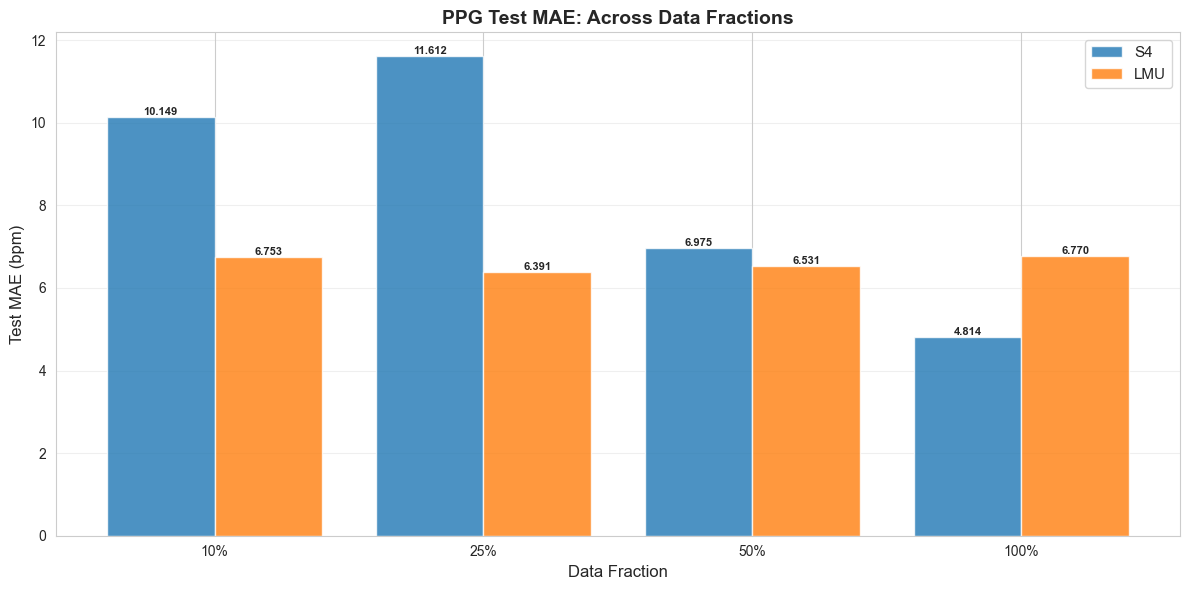

In [4]:
from src.eval.compare import plot_test_metric_comparison

plot_test_metric_comparison(
    all_results,
    metric_key='test_mae',
    title='PPG Test MAE: Across Data Fractions',
    ylabel='Test MAE (bpm)',
    save_path=str(compare_folder / 'test_mae_comparison.png')
)

## 4. Test RMSE Comparison

Bar chart showing test RMSE for each model and data fraction.


Plot saved to: figs/test_rmse_comparison.png


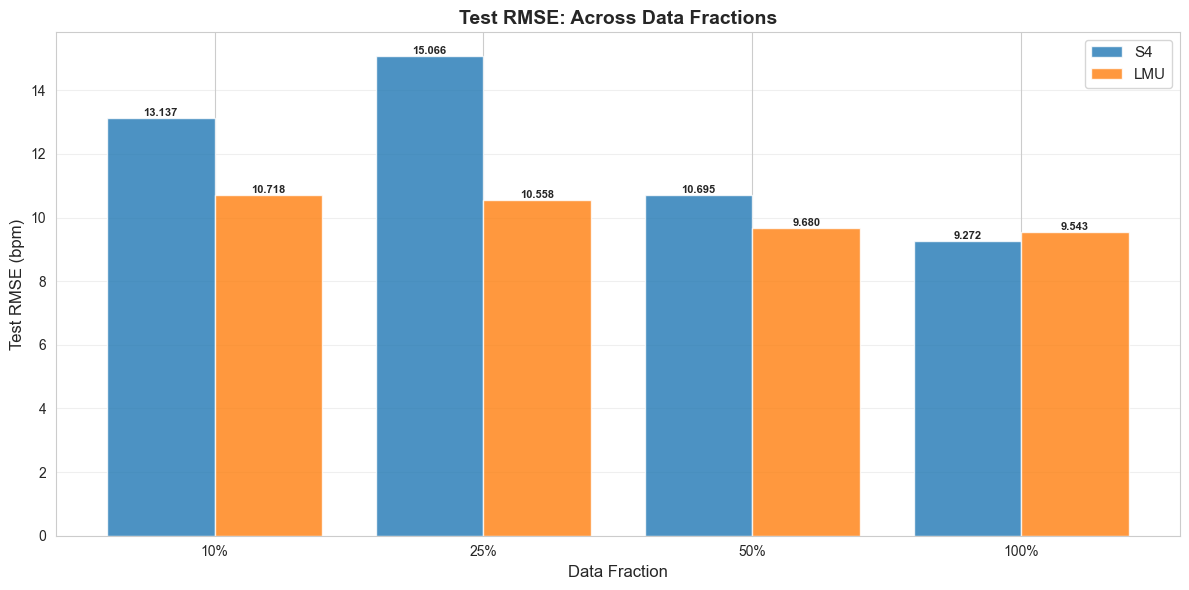

In [5]:
plot_test_metric_comparison(
    all_results,
    metric_key='test_rmse',
    title='Test RMSE: Across Data Fractions',
    ylabel='Test RMSE (bpm)',
    save_path=str(compare_folder / 'test_rmse_comparison.png')
)

## 5. Test Set Data Efficiency

Which model generalizes better with limited training data?


Plot saved to: figs/test_data_efficiency.png


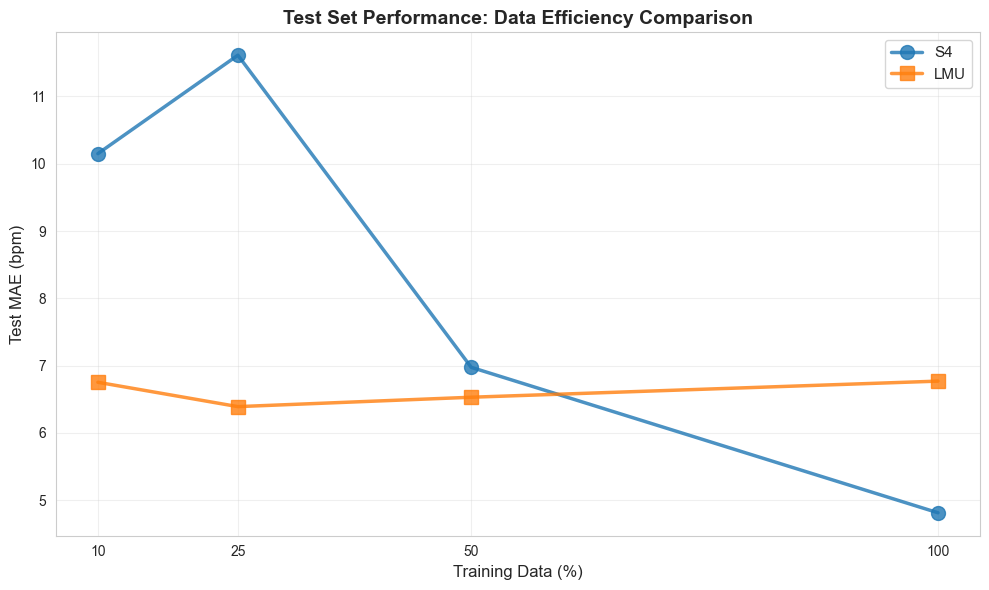

In [6]:
from src.eval.compare import plot_test_data_efficiency

plot_test_data_efficiency(
    all_results,
    metric_key='test_mae',
    ylabel='Test MAE (bpm)',
    save_path=str(compare_folder / 'test_data_efficiency.png')
)

## 6. Test Performance Heatmaps

Visual comparison of test set performance across models and data fractions.


Plot saved to: figs/test_performance_heatmap.png


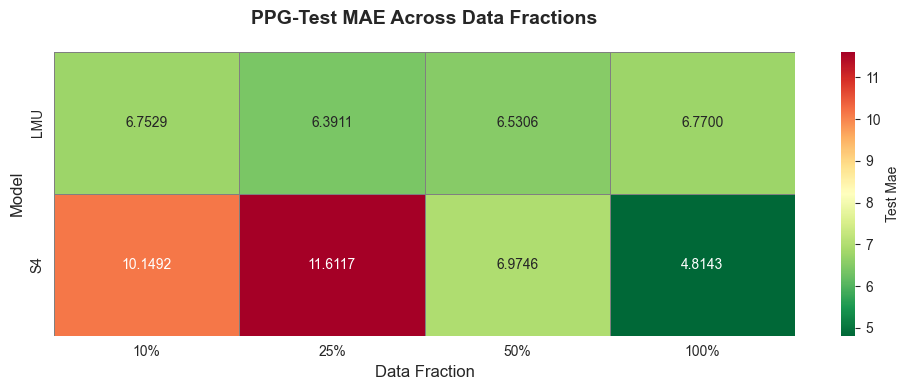

In [7]:
from src.eval.compare import plot_performance_heatmap

plot_performance_heatmap(
    all_results,
    metric_key='test_mae',
    title='PPG-Test MAE Across Data Fractions',
    annot_format='.4f',
    save_path=str(compare_folder / 'test_performance_heatmap.png')
)
